# ROC Comparison: Matched Filter vs Energy Statistic

1. We have observations of noise: $\vec x_0 = \vec n$
2. We also have observations of noise + signal: $\vec x_1 = \vec n + \vec s$
3. Note We generate white Gaussian noise so that the inverse noise covariance matrix $C^{-1} = I_{N \times N}$.


### Matched filter statistic
Let $h$ be the normalized filter
$c_{MF} = (x, h) = (C^{-1})_{ij} x_i h_j = x_i h_i$.

### Energy statistic

In this case we define a non-linear detection statistic
$ c_E = \sum_i x_i^2$


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(1234)

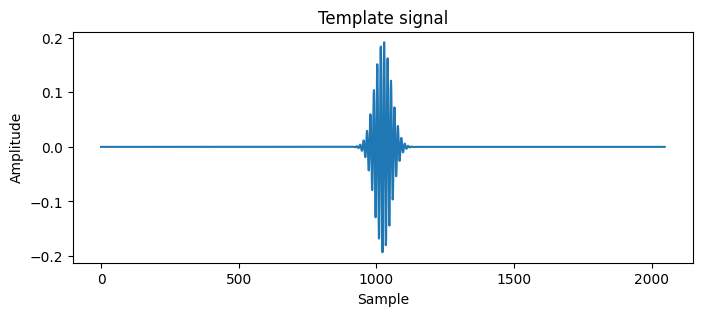

In [76]:
N = 2048
t = np.arange(N)

f0 = 0.08
sigma = 30

s = np.sin(2*np.pi*f0*t) * np.exp(-(t-N/2)**2/(2*sigma**2))
s /= np.sqrt(np.sum(s**2)) #-- normalization

plt.figure(figsize=(8,3))
plt.plot(s)
plt.title("Template signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [77]:
sigma_n = 1.0
rho_target = 1.5
A = rho_target * sigma_n
ntrials = 1000

In [78]:
#-- observation of noisy data only
x0 = sigma_n * np.random.randn(ntrials, N)

mf0 = x0 @ s
en0 = np.sum(x0**2, axis=1)

In [79]:
#-- observation of noisy data + a signal
#x1 = sigma_n * np.random.randn(ntrials, N)
x1 = x0 + A*s

mf1 = x1 @ s
en1 = np.sum(x1**2, axis=1)

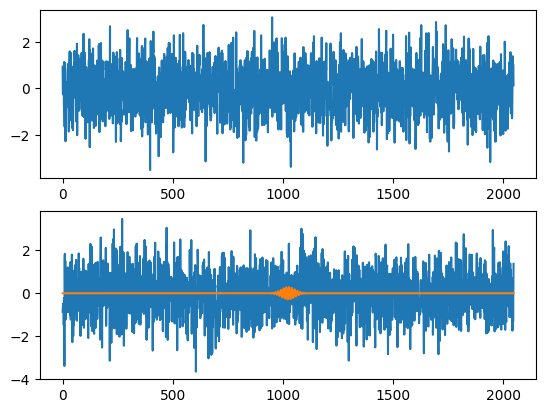

In [80]:
plt.subplot(2, 1, 1)
plt.plot(x0[23,:])

plt.subplot(2, 1, 2)
plt.plot(x1[12,:])
plt.plot(A*s)


In [81]:
def roc_curve_from_scores(background, foreground, npts=500):

    thresholds = np.linspace(
        min(background.min(), foreground.min()),
        max(background.max(), foreground.max()),
        npts
    )

    pfa = np.zeros_like(thresholds)
    pd  = np.zeros_like(thresholds)

    for i, thr in enumerate(thresholds):
        pfa[i] = np.mean(background > thr)
        pd[i]  = np.mean(foreground > thr)

    return pfa, pd

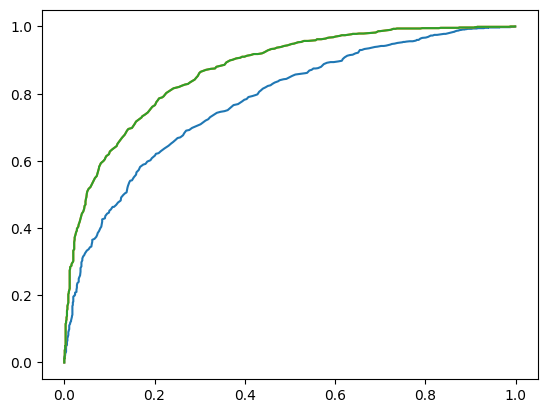

In [82]:
pfa_mf, pd_mf = roc_curve_from_scores(mf0, mf1)
pfa_en, pd_en = roc_curve_from_scores(energy0, energy1)
plt.plot(pfa_en, pd_en, pfa_mf, pd_mf)
plt.plot(pfa_mf, pd_mf)


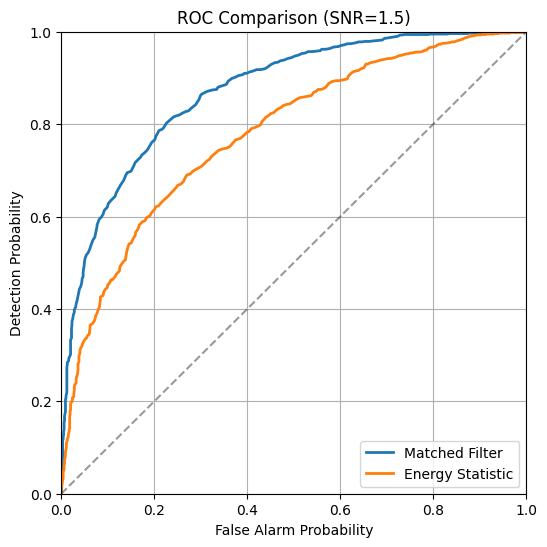

In [83]:
plt.figure(figsize=(6,6))

plt.plot(pfa_mf, pd_mf, lw=2, label="Matched Filter")
plt.plot(pfa_en, pd_en, lw=2, label="Energy Statistic")

plt.plot([0,1],[0,1],'k--',alpha=0.4)

plt.xlim(0,1)
plt.ylim(0,1)

plt.xlabel("False Alarm Probability")
plt.ylabel("Detection Probability")
plt.title(f"ROC Comparison (SNR={rho_target})")

plt.legend()
plt.grid(True)
plt.show()

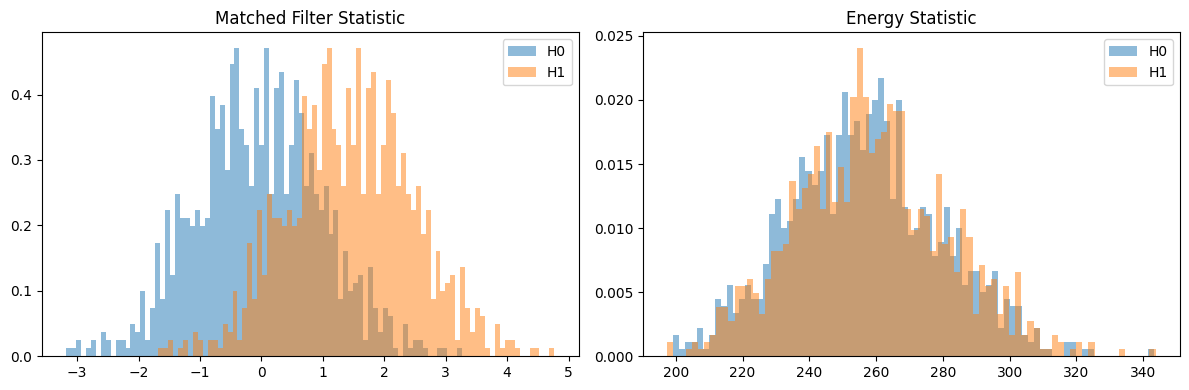

In [54]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

plt.hist(mf0, bins=80, density=True, alpha=0.5, label='H0')
plt.hist(mf1, bins=80, density=True, alpha=0.5, label='H1')

plt.title('Matched Filter Statistic')
plt.legend()

plt.subplot(1,2,2)

plt.hist(en0,bins=80, density=True, alpha=0.5, label='H0')
plt.hist(en1,bins=80, density=True, alpha=0.5, label='H1')

plt.title('Energy Statistic')
plt.legend()

plt.tight_layout()
plt.show()

### Questions

1. From the ROC curve for the two statistic - what can you conclude about their ability to detect signals in noise?
2. What happens for progressively louder signals - how do the ROC curves change?
3. Lets try a different statistic - peak statistic: $c_{p} = \max_i |x_i|$. Plot overlay the ROC curve for this new statistic.
4. What happens when the embedded signal is very loud? Can we make use of any of the above three statistic to detect the signal?
5. What happens for weak signals where their amplitude is comparable to the noise $\sigma$?